In [10]:
# Make sure the .csv file is in the same folder with program
dataset = pandas.read_csv('redwine.csv', names=names)

--- Descriptive Statistics: Low Volatile Acidity ---
count    783.000000
mean       5.890166
std        0.798459
min        3.000000
25%        5.000000
50%        6.000000
75%        6.000000
max        8.000000
Name: quality, dtype: float64

--- Descriptive Statistics: High Volatile Acidity ---
count    816.000000
mean       5.392157
std        0.738519
min        3.000000
25%        5.000000
50%        5.000000
75%        6.000000
max        8.000000
Name: quality, dtype: float64


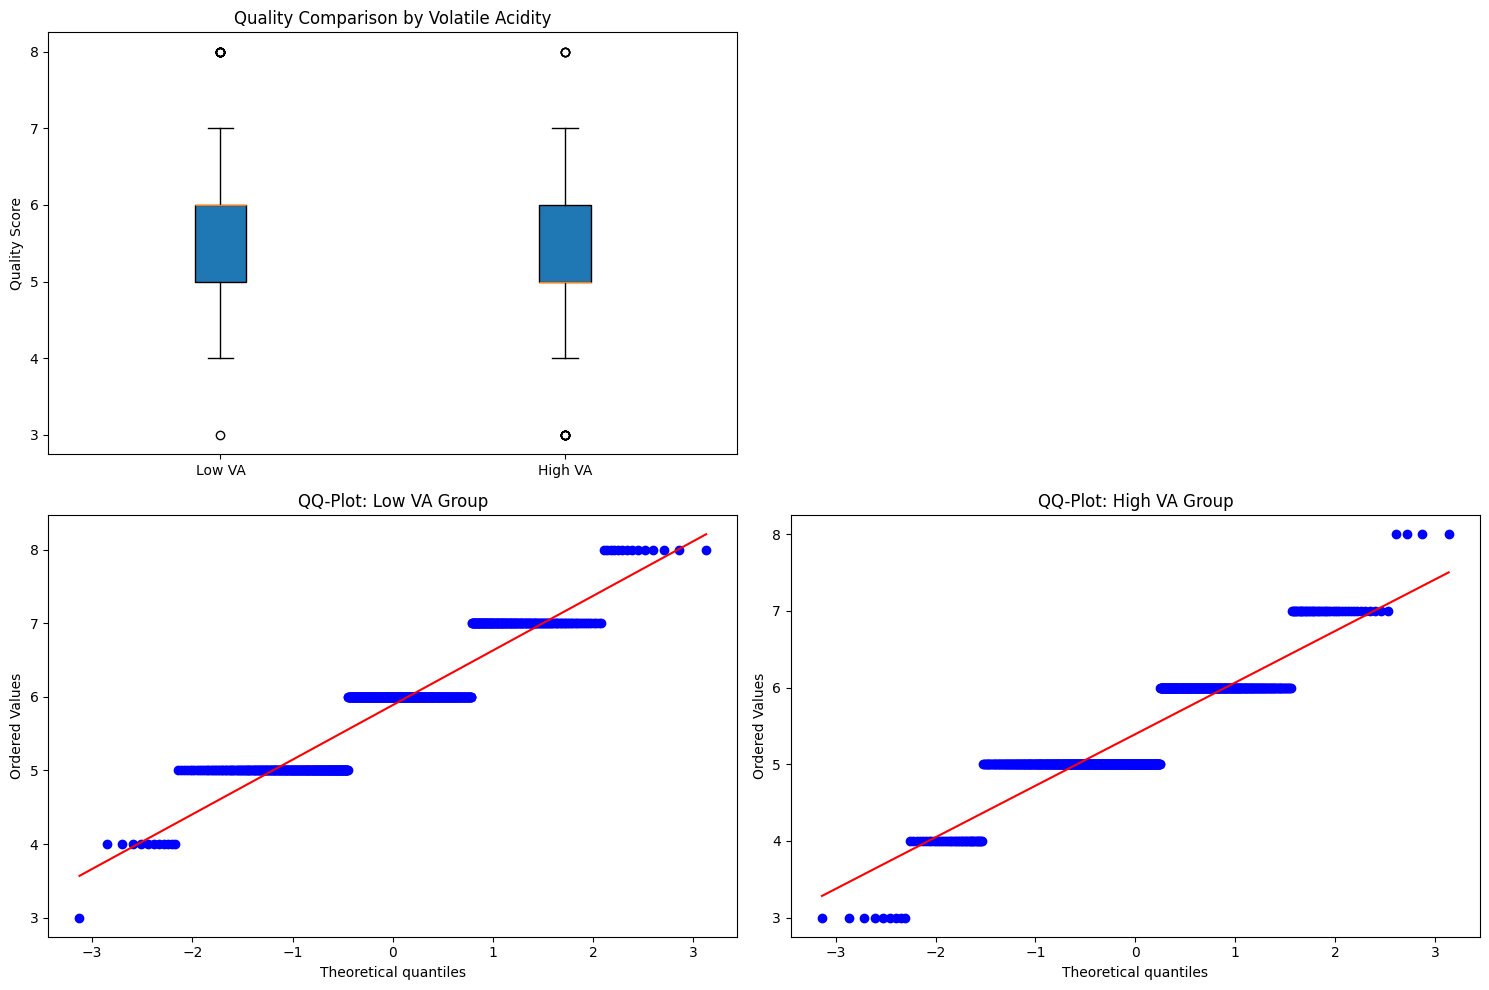


Variance (Low VA): 0.6375
Variance (High VA): 0.5454

--- Welch's T-Test Results ---
T-statistic: 12.9337
P-value: 0.00000000000000000000000000000000000097008637747666

Conclusion: P-value < 0.05, Reject the Null Hypothesis (H0).
Statistical evidence suggests that red wines with lower volatile acidity receive significantly higher quality scores.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, probplot

# 1. Load Data: Ensure the delimiter is set to ';' as seen in your file
df = pd.read_csv('redwine.csv', sep=';')

# 2. Data Preparation: Split the data into two groups based on the median of 'volatile acidity'
median_va = df['volatile acidity'].median()

# Grouping into High Volatile Acidity and Low Volatile Acidity
high_va_quality = df.loc[df['volatile acidity'] >= median_va, 'quality'].dropna()
low_va_quality = df.loc[df['volatile acidity'] < median_va, 'quality'].dropna()

# 3. Descriptive Statistics
print("--- Descriptive Statistics: Low Volatile Acidity ---")
print(low_va_quality.describe())
print("\n--- Descriptive Statistics: High Volatile Acidity ---")
print(high_va_quality.describe())

# 4. Visualization
plt.figure(figsize=(15, 10))

# 4.1 Boxplot (Quality Comparison)
plt.subplot(2, 2, 1)
# Note: Median line is the orange line
plt.boxplot([low_va_quality, high_va_quality], tick_labels=['Low VA', 'High VA'], patch_artist=True)
plt.title('Quality Comparison by Volatile Acidity')
plt.ylabel('Quality Score')

# 4.2 QQ-Plots (Testing for Normality)
# Step-like patterns appear due to discrete integer scores
plt.subplot(2, 2, 3)
probplot(low_va_quality, dist="norm", plot=plt)
plt.title('QQ-Plot: Low VA Group')

plt.subplot(2, 2, 4)
probplot(high_va_quality, dist="norm", plot=plt)
plt.title('QQ-Plot: High VA Group')

plt.tight_layout()
plt.show()

# 5. Hypothesis Testing
# H0: The mean quality of the two groups is the same
# H1: The mean quality of the Low VA group is significantly higher than the High VA group

# Check Variances
print(f"\nVariance (Low VA): {low_va_quality.var():.4f}")
print(f"Variance (High VA): {high_va_quality.var():.4f}")

# Perform Welch's T-Test (equal_var=False handles unequal variances)
t_stat, p_val = ttest_ind(low_va_quality, high_va_quality, equal_var=False, alternative='greater')

print("\n--- Welch's T-Test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.50f}")

alpha = 0.05
if p_val < alpha:
    print(f"\nConclusion: P-value < {alpha}, Reject the Null Hypothesis (H0).")
    print("Statistical evidence suggests that red wines with lower volatile acidity receive significantly higher quality scores.")
else:
    print(f"\nConclusion: P-value >= {alpha}, Fail to reject the Null Hypothesis (H0).")

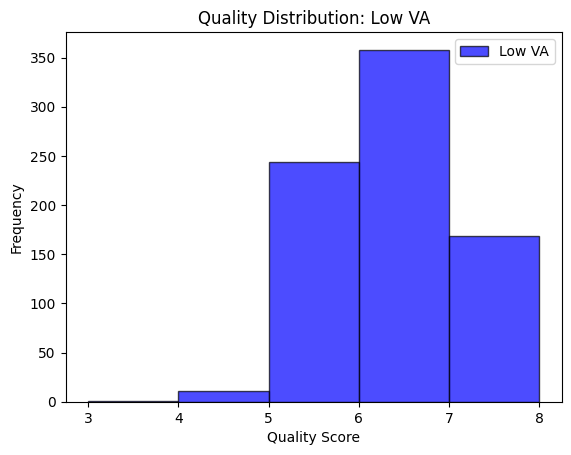

In [12]:
# 4.2 Histograms of frequency
plt.subplot(1, 1, 1)  
plt.hist(low_va_quality, bins=5, alpha=0.7, label='Low VA', color='blue', edgecolor='black')
plt.title('Quality Distribution: Low VA')
plt.xlabel('Quality Score')
plt.ylabel('Frequency')
plt.legend()

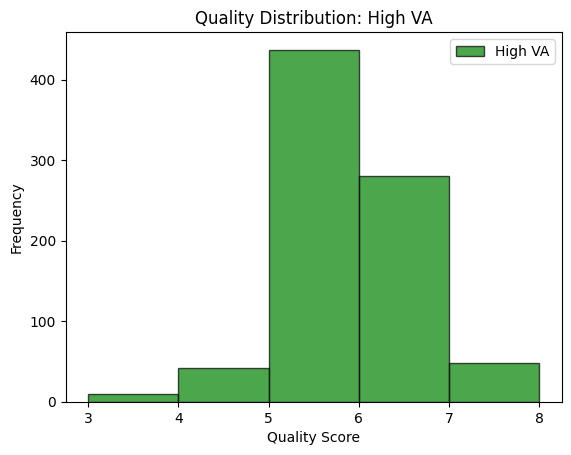

In [13]:
plt.subplot(1, 1, 1)  
plt.hist(high_va_quality, bins=5, alpha=0.7, label='High VA', color='green', edgecolor='black')
plt.title('Quality Distribution: High VA')
plt.xlabel('Quality Score')
plt.ylabel('Frequency')
plt.legend()